<a href="https://colab.research.google.com/github/engmodu/AIFEL_quest_eng/blob/main/NLP/NLP04/seq2seq_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seq2Seq + Bahdanau Attention 한→영 번역기

- 데이터 자동 다운로드

MAX_SAMPLES = 30000`, `EPOCHS = 50`

## 0. 환경 설치

In [1]:
# Colab 기준 설치 셀입니다. 로컬 Jupyter라면 apt 명령은 실패할 수 있지만, 다음 셀들이 최대한 폴백합니다.
import os, sys, subprocess, platform

IN_COLAB = 'google.colab' in sys.modules
print('IN_COLAB:', IN_COLAB)

if IN_COLAB:
    !apt-get update -qq
    !apt-get install -y fonts-nanum openjdk-17-jdk-headless -qq
    !pip install -q konlpy
    # Mecab은 환경에 따라 실패할 수 있어도 전체 실행은 계속됩니다.
    !bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) 2>/dev/null || echo "[INFO] mecab 설치 실패 가능: Okt 또는 기본 토큰화로 대체합니다."
else:
    print('로컬 환경입니다. 필요하면 직접 설치하세요: pip install konlpy')

IN_COLAB: True
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.0/438.0 kB 40.5 MB/s eta 0:00:00
Install mecab-ko
mecab-0.996-ko-0.9.2/
mecab-0.996-ko-0.9.2/example/
mecab-0.996-ko-0.9.2/example/example.cpp
mecab-0.996-ko-0.9.2/example/example_lattice.cpp
mecab-0.996-ko-0.9.2/example/example_lattice.c
mecab-0.996-ko-0.9.2/example/example.c
mecab-0.996-ko-0.9.2/example/thread_test.cpp
mecab-0.996-ko-0.9.2/me

## 1. 라이브러리 / 폰트 / 디바이스

In [2]:
import os
import re
import tarfile
import random
import urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device : {device}')

# 한글 폰트 자동 탐색
font_candidates = [
    '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf',
    '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    '/content/drive/MyDrive/font/nanum/NanumBarunGothic.ttf',
    '/content/drive/MyDrive/font/nanum/NanumGothic.ttf',
    './font/nanum/NanumBarunGothic.ttf',
    './font/nanum/NanumGothic.ttf',
]

fontpath = next((p for p in font_candidates if os.path.exists(p)), None)
fontprop = None

if fontpath:
    fontprop = fm.FontProperties(fname=fontpath, size=12)
    plt.rcParams['font.family'] = fontprop.get_name()
    print('사용 폰트:', fontpath)
else:
    print('[WARN] 나눔 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.')

plt.rcParams['axes.unicode_minus'] = False

PyTorch: 2.10.0+cu128
Device : cuda
사용 폰트: /usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf


## 2. 데이터 다운로드 / 압축 해제 / 파일 찾기

In [3]:
DATA_DIR = Path('./data')
DATA_DIR.mkdir(exist_ok=True)

KO_URL = 'https://raw.githubusercontent.com/haven-jeon/ko_en_neural_machine_translation/master/korean_parallel_corpora/korean-english-v1/korean-english-park.train.ko'
EN_URL = 'https://raw.githubusercontent.com/haven-jeon/ko_en_neural_machine_translation/master/korean_parallel_corpora/korean-english-v1/korean-english-park.train.en'

ko_path = DATA_DIR / 'korean-english-park.train.ko'
en_path = DATA_DIR / 'korean-english-park.train.en'

def download_if_missing(url, path):
    path = Path(path)
    if path.exists() and path.stat().st_size > 0:
        print('이미 있음:', path)
        return
    print('다운로드:', path)
    urllib.request.urlretrieve(url, path)

# 1순위: raw 파일 직접 다운로드
try:
    download_if_missing(KO_URL, ko_path)
    download_if_missing(EN_URL, en_path)
except Exception as e:
    print('[WARN] 직접 다운로드 실패:', repr(e))

# 2순위: tar.gz가 현재 경로나 후보 경로에 있으면 압축 해제-
extract_dir = DATA_DIR
candidate_tar_paths = [
    Path('korean-english-park.train.tar.gz'),
    Path('work/korean-english-park.train.tar.gz'),
    Path('/content/korean-english-park.train.tar.gz'),
    Path('/content/drive/MyDrive/korean-english-park.train.tar.gz'),
    DATA_DIR / 'korean-english-park.train.tar.gz',
]

tar_path = next((p for p in candidate_tar_paths if p.exists()), None)
if tar_path:
    print('압축 파일 발견:', tar_path)
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(extract_dir)

# 최종적으로 .ko / .en 파일 재탐색
ko_files = sorted(DATA_DIR.rglob('*.ko')) + sorted(Path('.').rglob('*.ko'))
en_files = sorted(DATA_DIR.rglob('*.en')) + sorted(Path('.').rglob('*.en'))

if not ko_files or not en_files:
    raise FileNotFoundError('한국어(.ko) 또는 영어(.en) 파일을 찾지 못했습니다. data 폴더나 현재 폴더에 파일을 넣어주세요.')

ko_path = ko_files[0]
en_path = en_files[0]
print('한국어 파일:', ko_path)
print('영어 파일  :', en_path)

with open(ko_path, encoding='utf-8') as f:
    kor_lines = f.read().splitlines()
with open(en_path, encoding='utf-8') as f:
    eng_lines = f.read().splitlines()

min_len = min(len(kor_lines), len(eng_lines))
kor_lines = kor_lines[:min_len]
eng_lines = eng_lines[:min_len]

print('문장 쌍 개수:', len(kor_lines))
print('예시 KO:', kor_lines[0])
print('예시 EN:', eng_lines[0])

다운로드: data/korean-english-park.train.ko
다운로드: data/korean-english-park.train.en
한국어 파일: data/korean-english-park.train.ko
영어 파일  : data/korean-english-park.train.en
문장 쌍 개수: 96215
예시 KO: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
예시 EN: Much of personal computing is about "can you top this?"


## 3. 전처리 / 형태소 분석

In [4]:
def preprocess_eng(sentence: str) -> str:
    sentence = sentence.lower().strip()
    sentence = re.sub(r'([?.!,])', r' \1 ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence)
    sentence = re.sub(r'[^a-zA-Z?.!,]+', ' ', sentence)
    return sentence.strip()


def preprocess_kor(sentence: str) -> str:
    sentence = sentence.strip()
    sentence = re.sub(r'([?.!,])', r' \1 ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence)
    sentence = re.sub(r'[^가-힣a-zA-Z0-9?.!,\s]+', ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence)
    return sentence.strip()

# 한국어 토크나이저: Mecab -> Okt -> 기본 split 폴백
try:
    from konlpy.tag import Mecab
    _mecab = Mecab()
    def kor_tokenize(s):
        return _mecab.morphs(s)
    TOKENIZER_NAME = 'Mecab'
except Exception as e1:
    try:
        from konlpy.tag import Okt
        _okt = Okt()
        def kor_tokenize(s):
            return _okt.morphs(s)
        TOKENIZER_NAME = 'Okt'
    except Exception as e2:
        def kor_tokenize(s):
            return s.split()
        TOKENIZER_NAME = 'basic split'

print('한국어 토크나이저:', TOKENIZER_NAME)

한국어 토크나이저: Okt


## 4. 병렬쌍 정제 / 토큰화 / 길이 필터

In [5]:
MAX_TOKEN_LEN = 40
MAX_SAMPLES = 30000  # 빠른 실행용. 성능을 높이려면 None 또는 더 큰 수로 변경.

# 병렬쌍 유지하면서 중복 제거
pairs = list(dict.fromkeys(zip(kor_lines, eng_lines)))
random.shuffle(pairs)
if MAX_SAMPLES is not None:
    pairs = pairs[:MAX_SAMPLES]

kor_corpus = []
eng_corpus = []

for kor, eng in tqdm(pairs, desc='전처리 중'):
    kor_clean = preprocess_kor(kor)
    eng_clean = preprocess_eng(eng)
    if not kor_clean or not eng_clean:
        continue

    kor_tokens = kor_tokenize(kor_clean)
    eng_tokens = ['<start>'] + eng_clean.split() + ['<end>']

    if 1 <= len(kor_tokens) <= MAX_TOKEN_LEN and 2 <= len(eng_tokens) <= MAX_TOKEN_LEN:
        kor_corpus.append(kor_tokens)
        eng_corpus.append(eng_tokens)

print('사용 문장 쌍:', len(kor_corpus))
print('KO tokens:', kor_corpus[0])
print('EN tokens:', eng_corpus[0])

전처리 중:   0%|          | 0/30000 [00:00<?, ?it/s]

사용 문장 쌍: 25432
KO tokens: ['미군', '의', 'US', '193', '첩보', '위성', '은', '지난', '2006년', '12월', '발사', '됐으나', '발사', '와', '동시', '에', '동력', '을', '잃었으며', '중앙', '컴퓨터', '가', '작동', '을', '멈춰', '현재', '는', '제어', '가', '불가능한', '상태', '다', '.']
EN tokens: ['<start>', 'it', 'lost', 'power', 'and', 'its', 'central', 'computer', 'failed', 'almost', 'immediately', 'afterward', ',', 'leaving', 'it', 'uncontrollable', '.', '<end>']


## 5. Tokenizer / Dataset / DataLoader

In [6]:
class SimpleTokenizer:
    def __init__(self, vocab_size=10000):
        self.vocab_size = vocab_size
        self.pad_token = '<pad>'
        self.unk_token = '<unk>'
        self.start_token = '<start>'
        self.end_token = '<end>'
        self.pad_id = 0
        self.unk_id = 1
        self.start_id = 2
        self.end_id = 3
        self.word2idx = {}
        self.idx2word = {}

    def fit(self, corpus):
        counter = Counter()
        for tokens in corpus:
            counter.update(tokens)

        self.word2idx = {
            self.pad_token: self.pad_id,
            self.unk_token: self.unk_id,
            self.start_token: self.start_id,
            self.end_token: self.end_id,
        }
        for word, _ in counter.most_common(self.vocab_size - len(self.word2idx)):
            if word not in self.word2idx:
                self.word2idx[word] = len(self.word2idx)
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

    def encode(self, tokens):
        return [self.word2idx.get(tok, self.unk_id) for tok in tokens]

    def decode(self, ids, remove_special=True):
        words = []
        for idx in ids:
            word = self.idx2word.get(int(idx), self.unk_token)
            if remove_special and word in {self.pad_token, self.start_token}:
                continue
            if remove_special and word == self.end_token:
                break
            words.append(word)
        return words

    def __len__(self):
        return len(self.word2idx)

VOCAB_SIZE = 15000
kor_tokenizer = SimpleTokenizer(vocab_size=VOCAB_SIZE)
eng_tokenizer = SimpleTokenizer(vocab_size=VOCAB_SIZE)
kor_tokenizer.fit(kor_corpus)
eng_tokenizer.fit(eng_corpus)

kor_tensor = [kor_tokenizer.encode(tokens) for tokens in kor_corpus]
eng_tensor = [eng_tokenizer.encode(tokens) for tokens in eng_corpus]

print('한국어 vocab:', len(kor_tokenizer))
print('영어 vocab  :', len(eng_tokenizer))

class TranslationDataset(Dataset):
    def __init__(self, src_data, trg_data, max_len=40, pad_id=0):
        self.src_data = src_data
        self.trg_data = trg_data
        self.max_len = max_len
        self.pad_id = pad_id

    def __len__(self):
        return len(self.src_data)

    def _pad(self, ids, length):
        ids = ids[:length]
        return ids + [self.pad_id] * (length - len(ids))

    def __getitem__(self, idx):
        src_ids = self.src_data[idx]
        trg_ids = self.trg_data[idx]

        src_ids = self._pad(src_ids, self.max_len)
        trg_input = self._pad(trg_ids[:-1], self.max_len)
        trg_label = self._pad(trg_ids[1:], self.max_len)

        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(trg_input, dtype=torch.long),
            torch.tensor(trg_label, dtype=torch.long),
        )

BATCH_SIZE = 64
dataset = TranslationDataset(kor_tensor, eng_tensor, max_len=MAX_TOKEN_LEN, pad_id=kor_tokenizer.pad_id)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

batch = next(iter(train_loader))
print([x.shape for x in batch])

한국어 vocab: 15000
영어 vocab  : 14998
[torch.Size([64, 40]), torch.Size([64, 40]), torch.Size([64, 40])]


## 6. 모델 정의

In [7]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, hidden_dim)
        # encoder_outputs: (src_len, batch, hidden_dim)
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)      # (batch, src_len, hidden)
        enc = encoder_outputs.permute(1, 0, 2)                 # (batch, src_len, hidden)
        energy = torch.tanh(self.W1(enc) + self.W2(hidden))
        score = self.v(energy).squeeze(2)                      # (batch, src_len)
        return torch.softmax(score, dim=1)

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout=0.1):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(emb_dim + hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(emb_dim + hidden_dim * 2, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input: (batch,)
        embedded = self.dropout(self.embedding(input.unsqueeze(0)))       # (1,batch,emb)

        a = self.attention(hidden[-1], encoder_outputs)                   # (batch,src_len)
        a_unsq = a.unsqueeze(1)                                           # (batch,1,src_len)
        enc = encoder_outputs.permute(1, 0, 2)                            # (batch,src_len,hidden)
        context = torch.bmm(a_unsq, enc).permute(1, 0, 2)                 # (1,batch,hidden)

        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)

        prediction = self.fc_out(torch.cat((
            output.squeeze(0),
            context.squeeze(0),
            embedded.squeeze(0)
        ), dim=1))
        return prediction, hidden, a

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=40, start_id=2, end_id=3):
        encoder_outputs, hidden = self.encoder(src)
        batch_size = src.shape[1]
        outputs = []
        attentions = []

        if trg is not None:
            input_token = trg[0]
            for t in range(trg.shape[0]):
                input_token = trg[t]
                output, hidden, attn = self.decoder(input_token, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
        else:
            input_token = torch.full((batch_size,), start_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for _ in range(max_len):
                output, hidden, attn = self.decoder(input_token, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
                top1 = output.argmax(1)
                input_token = top1
                finished |= top1.eq(end_id)
                if finished.all():
                    break

        return torch.cat(outputs, dim=0), torch.cat(attentions, dim=0)

INPUT_DIM = len(kor_tokenizer)
OUTPUT_DIM = len(eng_tokenizer)
EMB_DIM = 256
HID_DIM = 512

attention = BahdanauAttention(HID_DIM)
encoder = Encoder(INPUT_DIM, EMB_DIM, HID_DIM)
decoder = Decoder(OUTPUT_DIM, EMB_DIM, HID_DIM, attention)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(model.__class__.__name__)
print('parameters:', f'{sum(p.numel() for p in model.parameters()):,}')

Seq2SeqAttention
parameters: 30,569,622


## 7. 학습 / 평가 함수

In [8]:
PAD_ID = eng_tokenizer.pad_id
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

def train_step(model, data_loader, optimizer, criterion, epoch=1):
    model.train()
    total_loss = 0.0
    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch}', leave=True)

    for src, trg_input, trg_label in progress_bar:
        src = src.permute(1, 0).to(device)              # (seq,batch)
        trg_input = trg_input.permute(1, 0).to(device)  # (seq,batch)
        trg_label = trg_label.permute(1, 0).to(device)  # (seq,batch)

        optimizer.zero_grad()
        outputs, _ = model(src, trg_input, max_len=MAX_TOKEN_LEN)

        loss = criterion(outputs.reshape(-1, outputs.shape[-1]), trg_label.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=f'{loss.item():.4f}')

    return total_loss / max(1, len(data_loader))

def sentence_to_src_tensor(sentence, max_len=MAX_TOKEN_LEN):
    sentence_clean = preprocess_kor(sentence)
    src_tokens = kor_tokenize(sentence_clean)
    src_ids = kor_tokenizer.encode(src_tokens)[:max_len]
    src_ids = src_ids + [kor_tokenizer.pad_id] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(1).to(device)
    return src_tensor, src_tokens

@torch.no_grad()
def evaluate(sentence, model, max_len=MAX_TOKEN_LEN):
    model.eval()
    src_tensor, src_tokens = sentence_to_src_tensor(sentence, max_len=max_len)
    outputs, attentions = model(
        src_tensor,
        trg=None,
        max_len=max_len,
        start_id=eng_tokenizer.start_id,
        end_id=eng_tokenizer.end_id,
    )
    pred_ids = outputs.argmax(2).squeeze(1).detach().cpu().tolist()
    pred_tokens = eng_tokenizer.decode(pred_ids, remove_special=True)
    attn = attentions.squeeze(1).detach().cpu().numpy()[:, :len(src_tokens)]
    return pred_tokens, src_tokens, attn

submission_examples = [
    ('K1', '오바마는 대통령이다.'),
    ('K2', '시민들은 도시 속에 산다.'),
    ('K3', '커피는 필요 없다.'),
    ('K4', '일곱 명의 사망자가 발생했다.'),
]

# 학습 전 결과 확인
for tag, sent in submission_examples:
    pred, _, _ = evaluate(sent, model)
    print(tag, sent, '=>', ' '.join(pred))

K1 오바마는 대통령이다. => loneliness pisco crimp truly listen marches abraham trends rods ramsey paulson describe qualifier survivors countdown interviews wendell fdic councilors hasn student president hardcore lhasa crumbled desks inhabitants safer w franz tejada approached contentious gotten sister nose carmakers obligations tripped wheeled
K2 시민들은 도시 속에 산다. => loneliness pisco crimp truly listen marches abraham trends rods ramsey paulson describe qualifier survivors countdown interviews mishandling uh behalf contract hopeless memorandum vista disoriented harassing examinations wait medicine mixing experts canary retail clutching infringement horses protester noise appearance intelligence heiress
K3 커피는 필요 없다. => loneliness pisco crimp truly listen marches abraham trends rods ramsey paulson describe qualifier survivors countdown interviews mishandling uh behalf contract hopeless memorandum vista disoriented harassing lieberman squads sector paulo miyazaki such der multiple campaigners jung c

## 8. 학습 실행

In [10]:
EPOCHS = 50  # 처음엔 빠르게 3. 제출/성능 확인용은 10 이상 권장.
train_losses = []
epoch_translations = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    train_losses.append(train_loss)

    current_results = {}
    print(f'\n[Epoch {epoch}] loss={train_loss:.4f}')
    for tag, sent in submission_examples:
        pred, _, _ = evaluate(sent, model)
        translation = ' '.join(pred)
        current_results[tag] = (sent, translation)
        print(f'{tag}) {sent} => {translation}')

    epoch_translations.append({
        'epoch': epoch,
        'loss': train_loss,
        'translations': current_results,
    })

Epoch 1:   0%|          | 0/398 [00:00<?, ?it/s]


[Epoch 1] loss=5.6512
K1) 오바마는 대통령이다. => obama s president elect barack obama .
K2) 시민들은 도시 속에 산다. => they are also to be <unk> .
K3) 커피는 필요 없다. => the dow is not to be a little bit .
K4) 일곱 명의 사망자가 발생했다. => the death toll were killed in the city of the city .


Epoch 2:   0%|          | 0/398 [00:00<?, ?it/s]


[Epoch 2] loss=4.5326
K1) 오바마는 대통령이다. => obama is expected to speak with the president .
K2) 시민들은 도시 속에 산다. => they were <unk> to the <unk> .
K3) 커피는 필요 없다. => the dow is not going to be .
K4) 일곱 명의 사망자가 발생했다. => the people were killed in the clashes , the associated press reported .


Epoch 3:   0%|          | 0/398 [00:00<?, ?it/s]

...


[Epoch 48] loss=0.3510
K1) 오바마는 대통령이다. => obama , the president elect
K2) 시민들은 도시 속에 산다. => foreigners come in cities as the city took and <unk> in cities across the city of <unk> .
K3) 커피는 필요 없다. => coffee is no need for islamic terrorist .
K4) 일곱 명의 사망자가 발생했다. => another suicide of people killed in the clashes .


Epoch 49:   0%|          | 0/398 [00:00<?, ?it/s]


[Epoch 49] loss=0.3485
K1) 오바마는 대통령이다. => obama , the south carolina .
K2) 시민들은 도시 속에 산다. => foreigners in the city world .
K3) 커피는 필요 없다. => when caffeine is a coffee table .
K4) 일곱 명의 사망자가 발생했다. => at least people were killed , and when people were killed .


Epoch 50:   0%|          | 0/398 [00:00<?, ?it/s]


[Epoch 50] loss=0.3438
K1) 오바마는 대통령이다. => obama , meanwhile , is a host .
K2) 시민들은 도시 속에 산다. => they did in the cities of the men .
K3) 커피는 필요 없다. => when caffeine is a coffee is .
K4) 일곱 명의 사망자가 발생했다. => deaths from north carolina in the town of the country .


## 9. Loss 시각화 / 제출 문장 출력

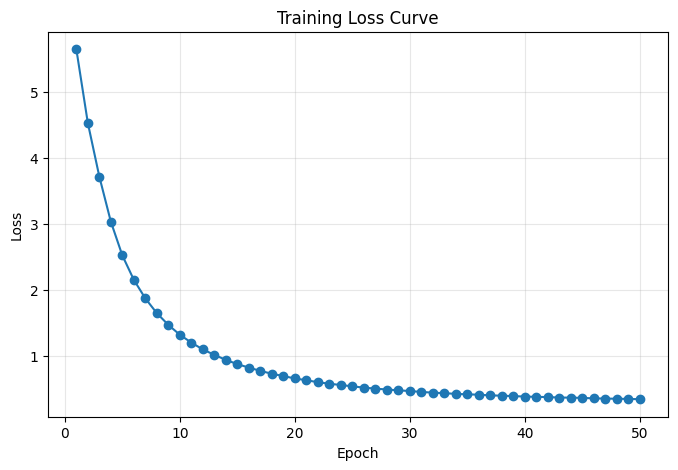

## 예문 ##
K1) 오바마는 대통령이다.
K2) 시민들은 도시 속에 산다.
K3) 커피는 필요 없다.
K4) 일곱 명의 사망자가 발생했다.

## 제출 ##
E1) obama , meanwhile , is a host . <end>
E2) they did in the cities of the men . <end>
E3) when caffeine is a coffee is . <end>
E4) deaths from north carolina in the town of the country . <end>

## Epoch별 번역 비교 ##

[Epoch 1] loss=5.6512
  K1) obama s president elect barack obama .
  K2) they are also to be <unk> .
  K3) the dow is not to be a little bit .
  K4) the death toll were killed in the city of the city .

[Epoch 2] loss=4.5326
  K1) obama is expected to speak with the president .
  K2) they were <unk> to the <unk> .
  K3) the dow is not going to be .
  K4) the people were killed in the clashes , the associated press reported .

[Epoch 3] loss=3.7191
  K1) obama is expected to be a good day .
  K2) they were subsequently to the <unk> .
  K3) the coffee is a coffee .
  K4) the toll was killed .

[Epoch 4] loss=3.0364
  K1) obama is expected to speak .
  K2) they are in the <unk> of the cit

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

print('## 예문 ##')
for tag, sent in submission_examples:
    print(f'{tag}) {sent}')

print('\n## 제출 ##')
for i, (tag, sent) in enumerate(submission_examples, start=1):
    pred, _, _ = evaluate(sent, model)
    print(f'E{i})', ' '.join(pred + ['<end>']))

print('\n## Epoch별 번역 비교 ##')
for record in epoch_translations:
    print(f"\n[Epoch {record['epoch']}] loss={record['loss']:.4f}")
    for tag, (sent, translation) in record['translations'].items():
        print(f'  {tag}) {translation}')

## 10. Attention Map

K1 오바마는 대통령이다. => obama , meanwhile , is a host .


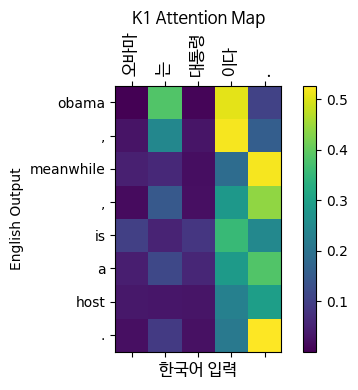

K2 시민들은 도시 속에 산다. => they did in the cities of the men .


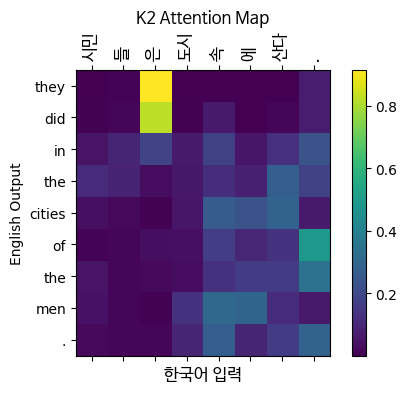

K3 커피는 필요 없다. => when caffeine is a coffee is .


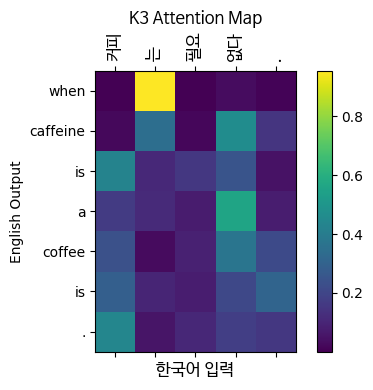

K4 일곱 명의 사망자가 발생했다. => deaths from north carolina in the town of the country .


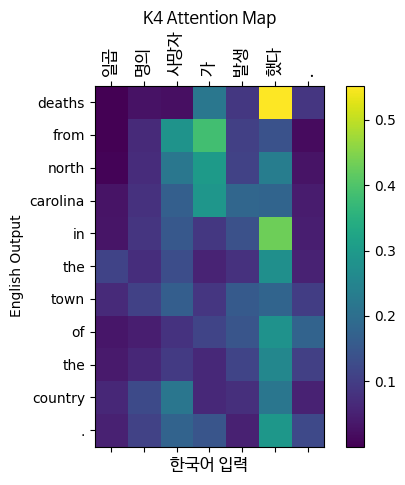

In [12]:
def plot_attention(attention, src_tokens, pred_tokens, title=''):
    if attention.size == 0 or len(src_tokens) == 0 or len(pred_tokens) == 0:
        print('[WARN] 표시할 attention이 없습니다.')
        return

    rows = min(len(pred_tokens), attention.shape[0])
    cols = min(len(src_tokens), attention.shape[1])
    att = attention[:rows, :cols]
    src = src_tokens[:cols]
    pred = pred_tokens[:rows]

    fig, ax = plt.subplots(figsize=(max(6, cols * 0.7), max(4, rows * 0.45)))
    im = ax.matshow(att)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(src)))
    ax.set_yticks(range(len(pred)))
    if fontprop is not None:
        ax.set_xticklabels(src, rotation=90, fontproperties=fontprop)
        ax.set_xlabel('한국어 입력', fontproperties=fontprop)
        ax.set_title(title, fontproperties=fontprop)
    else:
        ax.set_xticklabels(src, rotation=90)
        ax.set_xlabel('한국어 입력')
        ax.set_title(title)
    ax.set_yticklabels(pred)
    ax.set_ylabel('English Output')
    plt.tight_layout()
    plt.show()

for tag, sent in submission_examples:
    pred, src_tokens, attn = evaluate(sent, model)
    print(tag, sent, '=>', ' '.join(pred))
    plot_attention(attn, src_tokens, pred, title=f'{tag} Attention Map')

## 11. 모델 저장 / 불러오기

In [13]:
SAVE_PATH = 'seq2seq_attention_ko_en.pt'

torch.save({
    'model_state_dict': model.state_dict(),
    'kor_word2idx': kor_tokenizer.word2idx,
    'kor_idx2word': kor_tokenizer.idx2word,
    'eng_word2idx': eng_tokenizer.word2idx,
    'eng_idx2word': eng_tokenizer.idx2word,
    'config': {
        'INPUT_DIM': INPUT_DIM,
        'OUTPUT_DIM': OUTPUT_DIM,
        'EMB_DIM': EMB_DIM,
        'HID_DIM': HID_DIM,
        'MAX_TOKEN_LEN': MAX_TOKEN_LEN,
    }
}, SAVE_PATH)

print('저장 완료:', SAVE_PATH)

저장 완료: seq2seq_attention_ko_en.pt


총평 : 한글 데이터 및 전처리 부족으로 결과가 만족스럽지 않으나

deaths from north carolina in the town of the country
노스캐롤라이나주 시골 마을에서 발생한 사망자

비슷한 번역결과가 나와 부족한 부분을 찾아봐야 할 것 같습니다.